In [4]:
from cirq_sic import *
import matplotlib.pyplot as plt

# Scenario 1

Prepare the two qubits initially in $\frac{1}{\sqrt{2}} (|01\rangle + |10\rangle)$ and then act with $R_x(\theta) \otimes R_x(\theta)$. If $R_x(\theta) = e^{iX \theta}$, then this yields

$$ |\psi(\theta)\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix}2i \cos(\theta)\sin(\theta) \\
\cos(2\theta) \\ 
\cos(2\theta) \\
2i\cos(\theta)\sin(\theta)
 \end{pmatrix}$$

 Then measure in $X\otimes X$, $Y \otimes Y$, $Z \otimes Z$, etc, as in the single qubit case.

 The point is that we're exploring the symmetric subspace of two qubits, and $|00\rangle$ and $|11\rangle$ are boring since they are separable. Considering tensor square observables like $X\otimes X$ is like considering spin operators on an encoded qutrit since the symmetric subspace is three dimensional.

In [5]:
psi = np.array([0,1,1,0])/np.sqrt(2)
I, X, Y, Z = paulis
psi_theta = lambda theta: np.kron(sc.linalg.expm(1j*X*theta), sc.linalg.expm(1j*X*theta)) @ psi

def rho_theta(theta):
    ket = psi_theta(theta)
    return np.outer(ket, ket.conj())

E = wh_povm(d4_sic_fiducial_ket())

def sic_channel(rho):
    return sum([(e @ rho).trace()*e/e.trace() for e in E])

thetas = np.linspace(0, 2*np.pi, 100)
rho_thetas = [rho_theta(t) for t in thetas]
depolarized_rho_thetas = [sic_channel(rho) for rho in rho_thetas]

In [6]:
def scenario1(O, label):
    born_rule = np.array([(np.kron(O, O) @ rho).trace().real for rho in rho_thetas])
    ltp = np.array([(np.kron(O, O) @ rho).trace().real for rho in depolarized_rho_thetas])

    fig, ax = plt.subplots()
    ax.plot(thetas, born_rule, label="Born Rule")
    ax.plot(thetas, ltp, label="LTP")

    ax.set_xlabel(r"$\theta$")
    ax.set_ylabel(r"$\langle$%s$\rangle$" % label)
    ax.set_title(label)
    ax.legend() 
    plt.show()

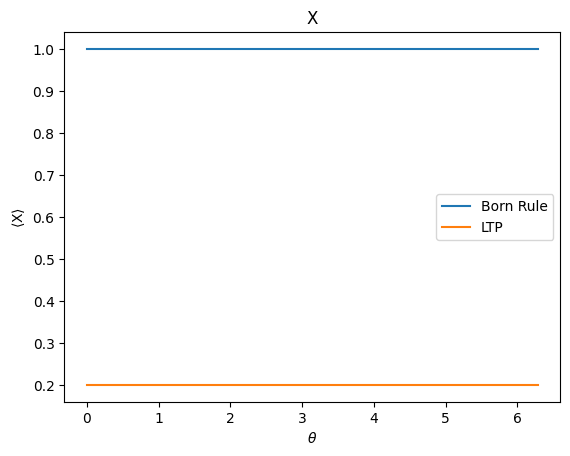

In [7]:
scenario1(X, "X")

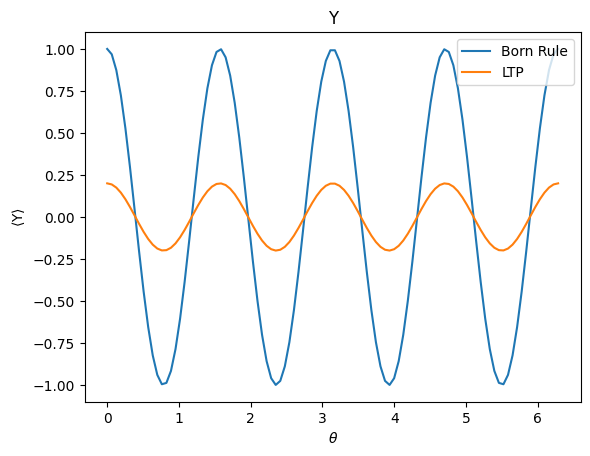

In [8]:
scenario1(Y, "Y")

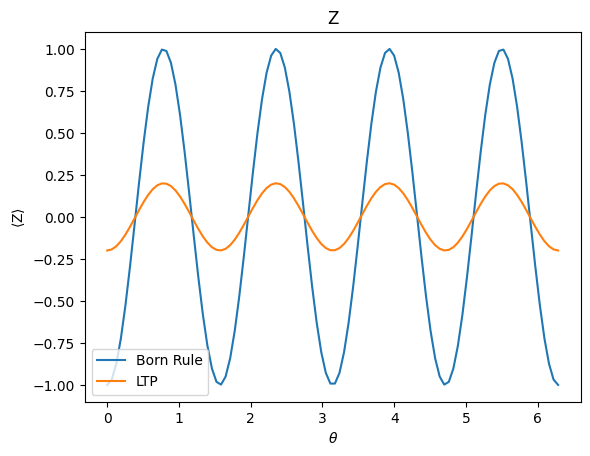

In [9]:
scenario1(Z, "Z")

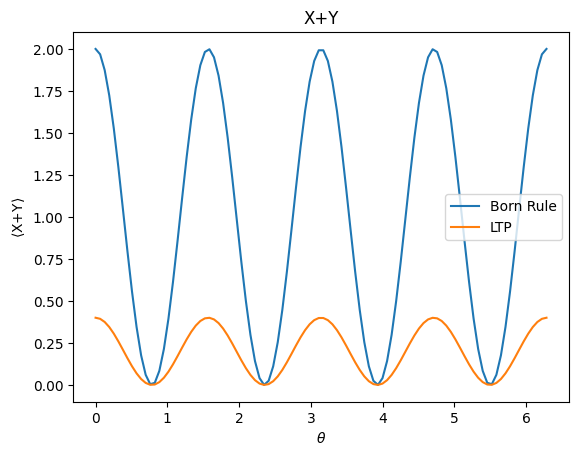

In [10]:
scenario1(X+Y, "X+Y")

## Scenario 2

Start off in the singlet state $\frac{1}{\sqrt{2}}(|01\rangle - |10\rangle)$. Keep that fixed, but consider the 1-parameter family of measurements on a single qubit.

$$ O(\theta) = \cos(\theta) Z + \sin(\theta) X$$

In the CHSH scenario, suppose Alice measures $\{ O(0), O(\pi/2) \}$ and Bob does $\{ O(\theta), O(-\theta)\}$.

$$ S = | \langle A_0 B_0\rangle + \langle A_0 B_1 \rangle + \langle A_1 B_0\rangle - \langle A_1 B_1\rangle|$$

The point is before we considered the symmetric subspace: now let's consider the antisymmetric.

In [28]:
def O(theta):
    return np.cos(theta)*Z + np.sin(theta)*X

psi2 = np.array([0,1,-1,0])/np.sqrt(2)
rho2 = np.outer(psi2, psi2.conj())
depolarized_rho2 = sic_channel(rho2)

obs = [lambda theta: np.kron(O(0), O(theta)),\
       lambda theta: np.kron(O(0), O(-theta)),\
       lambda theta: np.kron(O(np.pi/2), O(theta)),\
       lambda theta: np.kron(O(np.pi/2), O(-theta))]
f = lambda theta: obs[0](theta) + obs[1](theta) + obs[2](theta) - obs[3](theta)

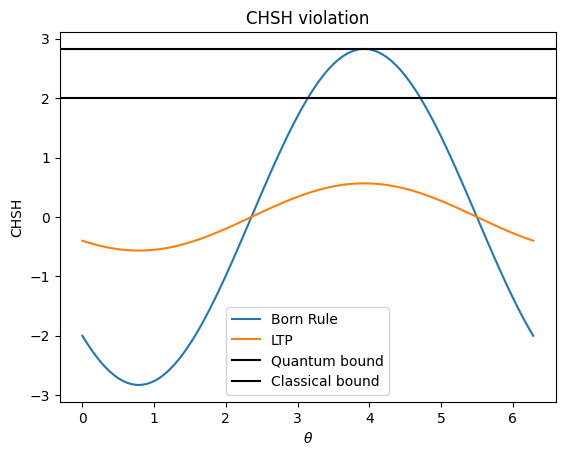

In [34]:
born_rule = np.array([(f(theta) @ rho2).trace().real for theta in thetas])
ltp = np.array([(f(theta) @ depolarized_rho2).trace().real for theta in thetas])

fig, ax = plt.subplots()
ax.plot(thetas, born_rule, label="Born Rule")
ax.plot(thetas, ltp, label="LTP")
ax.axhline(2*np.sqrt(2), label="Quantum bound", color="black")
ax.axhline(2, label="Classical bound", color="black")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel("CHSH")
ax.set_title("CHSH violation")
ax.legend() 
plt.show()